In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.drop("customerID", axis=1, inplace=True)

In [9]:
df["TotalCharges"].dtype

dtype('O')

In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [11]:
df["TotalCharges"].dtype

dtype('float64')

In [12]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [13]:
df.dropna(inplace=True)

In [14]:
df.shape

(7032, 20)

In [15]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

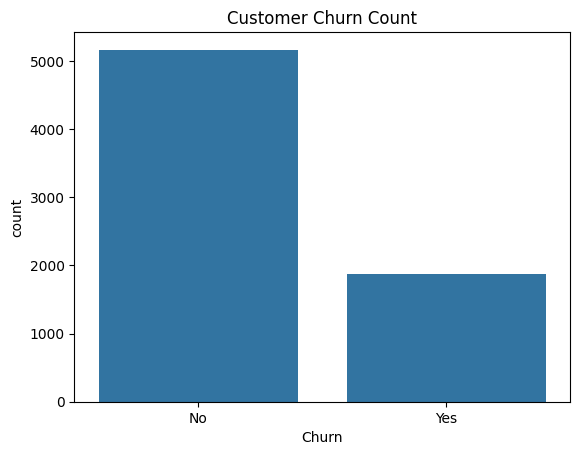

In [17]:
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Count")

plt.show()

In [18]:
df.select_dtypes(include=["int64", "float64"]).columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

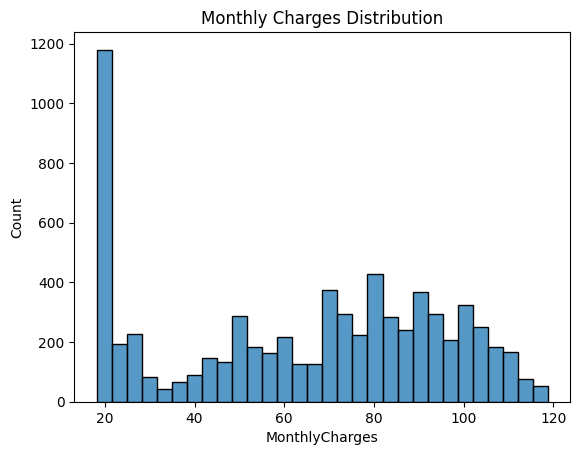

In [19]:
sns.histplot(df["MonthlyCharges"], bins=30)

plt.title("Monthly Charges Distribution")

plt.show()

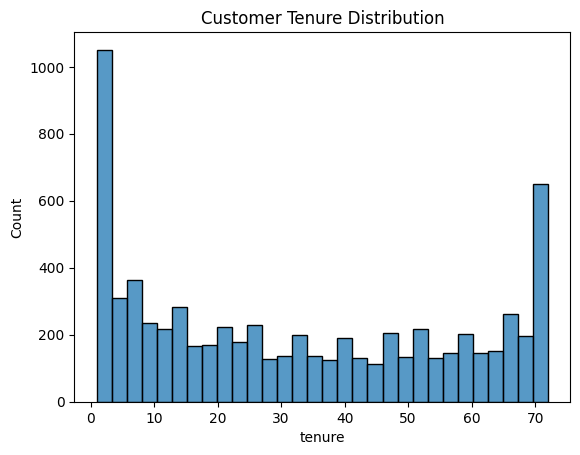

In [20]:
sns.histplot(df["tenure"], bins=30)

plt.title("Customer Tenure Distribution")

plt.show()

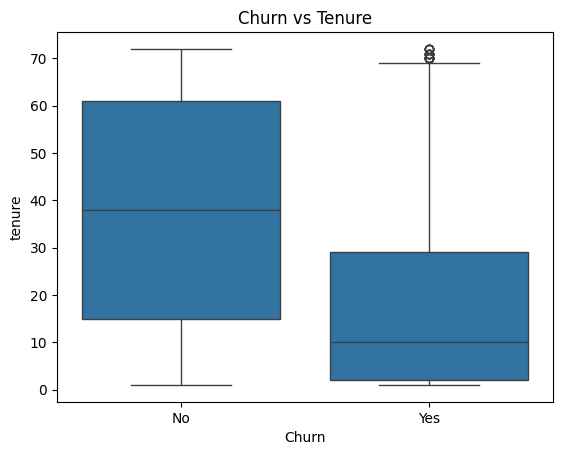

In [21]:
sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Churn vs Tenure")

plt.show()

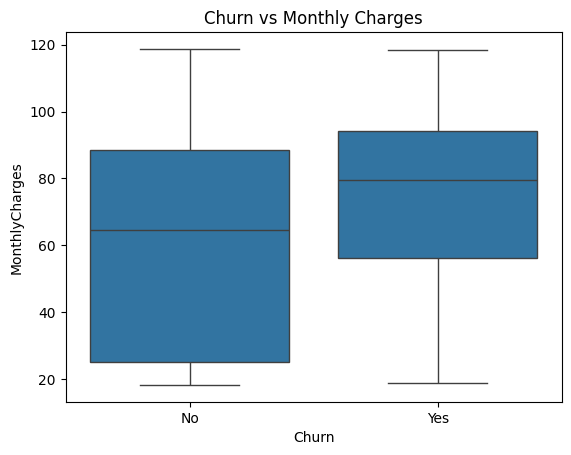

In [22]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Churn vs Monthly Charges")

plt.show()

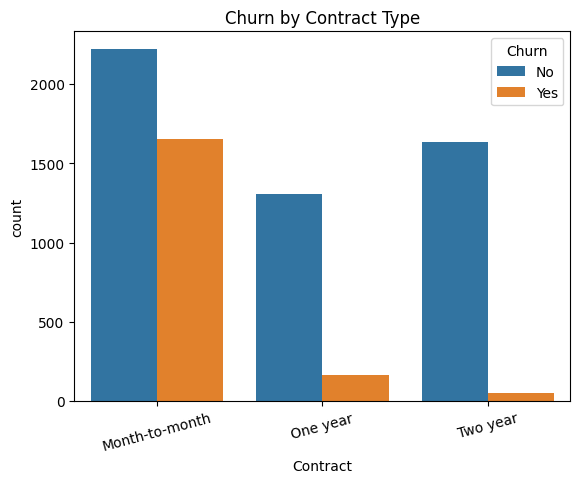

In [23]:
sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Churn by Contract Type")

plt.xticks(rotation=15)

plt.show()

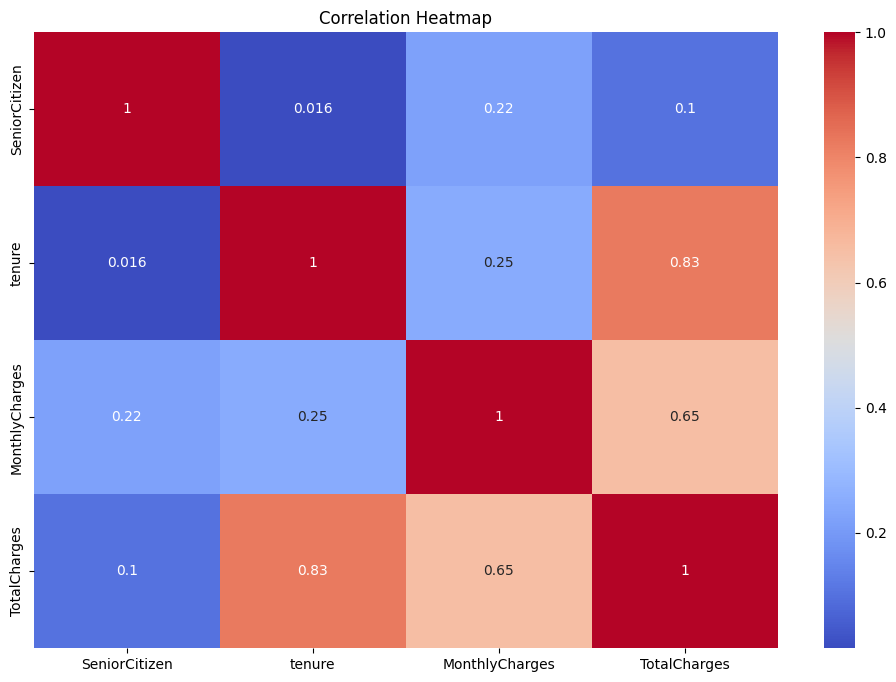

In [24]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [25]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [26]:
print(X.shape)

print(y.shape)

(7032, 19)
(7032,)


In [27]:
y = y.map({
    "Yes": 1,
    "No": 0
})

In [28]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [29]:
numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = X.select_dtypes(
    include=["object"]
).columns

In [30]:
print("Numerical Columns:")

print(numerical_columns)

print()

print("Categorical Columns:")

print(categorical_columns)

Numerical Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

Categorical Columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [31]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [32]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [33]:
from sklearn.model_selection import train_test_split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(5625, 30)
(1407, 30)
(5625,)
(1407,)


In [36]:
from sklearn.preprocessing import StandardScaler

In [37]:
scaler = StandardScaler()

In [38]:
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [39]:
print(X_train_scaled.shape)

print(X_test_scaled.shape)

(5625, 30)
(1407, 30)


In [40]:
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [41]:
lr_model = LogisticRegression()

In [42]:
lr_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression()

In [43]:
lr_pred = lr_model.predict(
    X_test_scaled
)

In [44]:
lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

print("Logistic Regression Accuracy:")

print(lr_accuracy)

Logistic Regression Accuracy:
0.7874911158493249


In [45]:
lr_cm = confusion_matrix(
    y_test,
    lr_pred
)

print(lr_cm)

[[915 118]
 [181 193]]


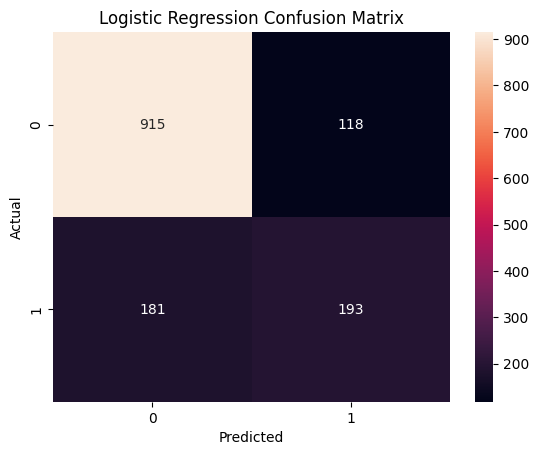

In [46]:
sns.heatmap(
    lr_cm,
    annot=True,
    fmt='d'
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [47]:
print(
    classification_report(
        y_test,
        lr_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [48]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

In [49]:
dt_model.fit(
    X_train_scaled,
    y_train
)

DecisionTreeClassifier(random_state=42)

In [50]:
dt_pred = dt_model.predict(
    X_test_scaled
)

In [51]:
dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

print("Decision Tree Accuracy:")

print(dt_accuracy)

Decision Tree Accuracy:
0.7256574271499645


In [52]:
print(
    classification_report(
        y_test,
        dt_pred
    )
)

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1033
           1       0.49      0.53      0.51       374

    accuracy                           0.73      1407
   macro avg       0.65      0.66      0.66      1407
weighted avg       0.73      0.73      0.73      1407



In [53]:
rf_model = RandomForestClassifier(
    random_state=42
)

In [54]:
rf_model.fit(
    X_train_scaled,
    y_train
)

RandomForestClassifier(random_state=42)

In [55]:
rf_pred = rf_model.predict(
    X_test_scaled
)

In [56]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:")

print(rf_accuracy)

Random Forest Accuracy:
0.7846481876332623


In [57]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.47      0.54       374

    accuracy                           0.78      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [58]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.787491
1,Decision Tree,0.725657
2,Random Forest,0.784648


In [59]:
importance = rf_model.feature_importances_

In [60]:
feature_names = X.columns

In [61]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

In [62]:
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

In [63]:
feature_importance_df.head(10)

,Feature,Importance
3,TotalCharges,0.193409
2,MonthlyCharges,0.169758
1,tenure,0.167572
10,InternetService_Fiber optic,0.039999
28,PaymentMethod_Electronic check,0.035016
13,OnlineSecurity_Yes,0.028905
25,Contract_Two year,0.028618
4,gender_Male,0.026971
19,TechSupport_Yes,0.025829
26,PaperlessBilling_Yes,0.025044


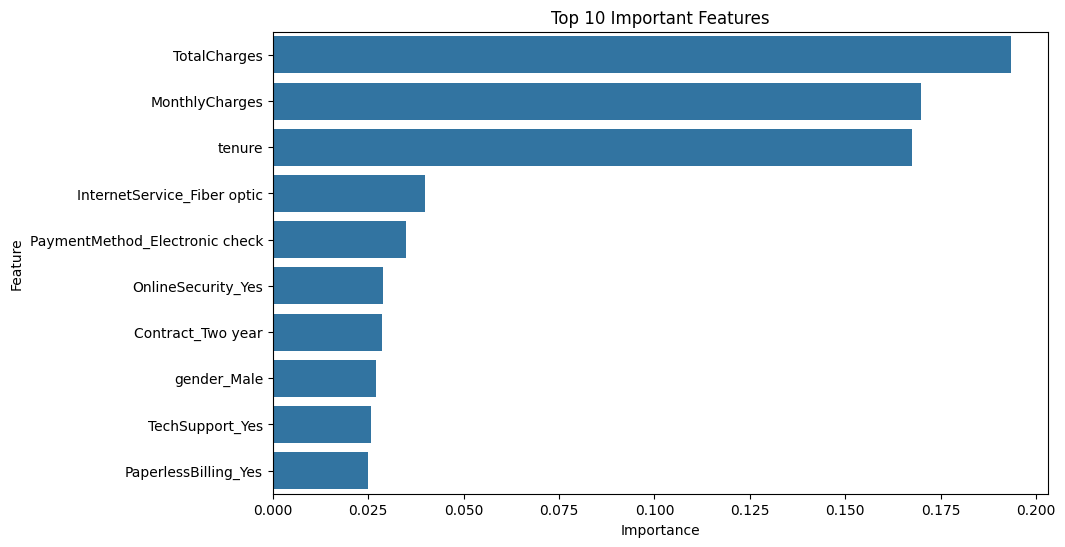

In [64]:
top_features = feature_importance_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top 10 Important Features")

plt.show()

# Business Insights

1. Customers with shorter tenure are more likely to churn.

2. Customers with higher monthly charges show increased churn tendency.

3. Month-to-month contract customers churn more frequently compared to yearly contract customers.

4. Contract type and pricing appear to strongly influence customer retention.

# Final Model Selection

Random Forest was selected as the final model because it achieved the best overall performance among the tested models.

# Conclusion

The project successfully predicts customer churn using machine learning techniques. The analysis identified important factors affecting churn, such as tenure, monthly charges, and contract type.

The Random Forest model achieved the best performance and can help businesses identify customers likely to leave, enabling proactive retention strategies.

In [65]:
from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

import joblib

In [66]:
pipeline_df = pd.read_csv("../data/churn.csv")

In [67]:
pipeline_df.drop(
    "customerID",
    axis=1,
    inplace=True
)

pipeline_df["TotalCharges"] = pd.to_numeric(
    pipeline_df["TotalCharges"],
    errors="coerce"
)

pipeline_df.dropna(inplace=True)

In [68]:
X_pipeline = pipeline_df.drop(
    "Churn",
    axis=1
)

y_pipeline = pipeline_df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [69]:
numerical_features = X_pipeline.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X_pipeline.select_dtypes(
    include=["object"]
).columns

In [70]:
numerical_transformer = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

In [71]:
categorical_transformer = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )
])

In [72]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [73]:
final_pipeline = Pipeline(steps=[
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        RandomForestClassifier(
            random_state=42
        )
    )
])

In [74]:
X_train_pipeline, X_test_pipeline, y_train_pipeline, y_test_pipeline = train_test_split(
    X_pipeline,
    y_pipeline,
    test_size=0.2,
    random_state=42
)

In [75]:
final_pipeline.fit(
    X_train_pipeline,
    y_train_pipeline
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model', RandomForestClassifier(random_state=42))])

In [76]:
pipeline_predictions = final_pipeline.predict(
    X_test_pipeline
)

In [77]:
pipeline_accuracy = accuracy_score(
    y_test_pipeline,
    pipeline_predictions
)

print(pipeline_accuracy)

0.7775408670931059


In [78]:
joblib.dump(
    final_pipeline,
    "../models/churn_pipeline.pkl"
)

['../models/churn_pipeline.pkl']

In [79]:
loaded_pipeline = joblib.load(
    "../models/churn_pipeline.pkl"
)

In [80]:
sample_customer = X_pipeline.iloc[[0]]

In [81]:
loaded_pipeline.predict(
    sample_customer
)

array([0])

In [82]:
import numpy as np

print("Actual test label counts:")
print(np.unique(y_test_pipeline, return_counts=True))

print("Predicted label counts:")
print(np.unique(pipeline_predictions, return_counts=True))

Actual test label counts:
(array([0, 1]), array([1033,  374]))
Predicted label counts:
(array([0, 1]), array([1122,  285]))


In [83]:
loaded_pipeline = joblib.load("../models/churn_pipeline.pkl")

sample_customer = X_pipeline.iloc[[0]]
print(loaded_pipeline.predict(sample_customer))

[0]


In [84]:
for i in range(5):
    sample = X_pipeline.iloc[[i]]
    pred = loaded_pipeline.predict(sample)[0]
    print(i, pred)

0 0
1 0
2 1
3 0
4 1
